# Klasifikasi Penyakit Buah Kakao (Versi Sederhana)

Alur: Import -> Eksplorasi Data -> Split Train/Val -> Balancing Kelas -> Augmentasi Offline -> Data Generator -> Bangun Model (EfficientNetB0) -> Training -> Evaluasi -> Grad-CAM

Catatan perbaikan dari versi sebelumnya:
- `BATCH_SIZE` dinaikkan dari 1 ke 16 (batch 1 membuat training sangat lambat dan tidak stabil)
- Augmentasi dibuat full offline: gambar hasil augmentasi disimpan ke disk sebelum training, generator tidak lagi mengandalkan augmentasi real-time
- Ditambahkan ringkasan waktu training dan tabel hyperparameter untuk keperluan presentasi
- Ditambahkan evaluasi tambahan: precision/recall/F1 per kelas dan kurva ROC

## 1. Import Library

In [1]:
import os, shutil, math, time
from random import sample

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import tensorflow as tf
import Augmentor

from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_recall_fscore_support, roc_curve, auc)
from sklearn.preprocessing import label_binarize

import warnings
warnings.filterwarnings("ignore")


In [2]:
import random
import numpy as np
import tensorflow as tf


SEED = 42

# 2. Kunci seed untuk bawaan Python & NumPy
random.seed(SEED)
np.random.seed(SEED)

# 3. Kunci seed untuk TensorFlow (mengunci inisialisasi bobot & dropout)
tf.random.set_seed(SEED)

# 4. Aktifkan determinisme TensorFlow (Sangat penting untuk TF versi >= 2.9)
# Ini memaksa semua operasi GPU/CPU berjalan dengan urutan yang sama persis
tf.config.experimental.enable_op_determinism()

## 2. Konfigurasi
Semua path dan hyperparameter dikumpulkan di satu tempat agar mudah diubah.

In [3]:
DATASET_PATH   = "cacao_photos"        # folder dataset asli (belum displit)
TRAIN_PATH     = "./train"
VAL_PATH       = "./test"
BEST_MODEL_DIR = "./best_models"
CLASSES        = ["black_pod_rot", "healthy", "pod_borer"]

IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 16          # sebelumnya 1 -> dinaikkan agar training lebih cepat & stabil
EPOCHS     = 30
VAL_RATIO  = 0.20
LEARNING_RATE = 0.0001

TARGET_PER_CLASS = 400   # target jumlah gambar tiap kelas setelah augmentasi offline


## 3. Eksplorasi Data Awal
Menghitung jumlah gambar tiap kelas pada dataset mentah.

In [4]:
for c in CLASSES:
    jumlah = len(os.listdir(f"{DATASET_PATH}/{c}"))
    print(f"{c:15s}: {jumlah} gambar")


black_pod_rot  : 943 gambar
healthy        : 3344 gambar
pod_borer      : 103 gambar


## 4. Siapkan Folder Kerja & Salin Dataset
Membuat folder `train_photos`, `val_photos`, `best_models`, lalu menyalin dataset mentah ke `train_photos` (hanya jika belum pernah dilakukan).

In [5]:
os.makedirs(TRAIN_PATH, exist_ok=True)
os.makedirs(BEST_MODEL_DIR, exist_ok=True)
for c in CLASSES:
    os.makedirs(f"{VAL_PATH}/{c}", exist_ok=True)

if not os.listdir(TRAIN_PATH):
    for c in CLASSES:
        shutil.copytree(f"{DATASET_PATH}/{c}", f"{TRAIN_PATH}/{c}")
    print("Dataset berhasil disalin ke train_photos.")
else:
    print("train_photos sudah terisi, proses salin dilewati.")


train_photos sudah terisi, proses salin dilewati.


## 5. Split ke Validation Set (20%)
Mengambil 20% gambar tiap kelas dari `train_photos` lalu memindahkannya ke `val_photos`.

In [6]:
# 1. Tentukan nama file indikator (bisa ditaruh di folder utama dataset Anda)
INDIKATOR_FILE = "split_selesai.marker"

def pindahkan_sebagian(sumber, tujuan, jumlah):
    """Pindahkan sejumlah file pertama dari folder sumber ke folder tujuan."""
    # Pastikan folder tujuan sudah dibuat, jika belum akan dibuat otomatis
    os.makedirs(tujuan, exist_ok=True)
    
    # Jika folder tujuan sudah berisi data, lewati folder ini (anti-double split per class)
    if os.listdir(tujuan):
        print(f"Folder {tujuan} sudah terisi, melewati...")
        return
        
    for file in os.listdir(sumber)[:jumlah]:
        shutil.move(os.path.join(sumber, file), os.path.join(tujuan, file))

# 2. Cek apakah file indikator sudah ada dari running sebelumnya
if os.path.exists(INDIKATOR_FILE):
    print("Maju logis: Proses split train/val sudah pernah dilakukan sebelumnya. Langkah ini dilewati.")
else:
    print("Memulai proses split train/val untuk pertama kalinya...")
    
    for c in CLASSES:
        sumber_dir = f"{TRAIN_PATH}/{c}"
        tujuan_dir = f"{VAL_PATH}/{c}"
        
        # Pastikan folder sumber ada sebelum melakukan listdir
        if os.path.exists(sumber_dir):
            jumlah_val = math.ceil(len(os.listdir(sumber_dir)) * VAL_RATIO)
            pindahkan_sebagian(sumber_dir, tujuan_dir, jumlah_val)
    
    # 3. Buat file indikator setelah seluruh loop kelas selesai dengan sukses
    with open(INDIKATOR_FILE, "w") as f:
        f.write("Proses split data berhasil dilakukan.")
        
    print("Split train/val selesai dan file indikator telah dibuat.")

Maju logis: Proses split train/val sudah pernah dilakukan sebelumnya. Langkah ini dilewati.


## 6. Balancing Kelas Healthy (Undersampling)
Jumlah kelas *Healthy* biasanya jauh lebih banyak dari *Black Pod Rot*, sehingga sebagian gambarnya dihapus secara acak agar jumlahnya seimbang.

In [7]:
# 1. Tentukan nama file indikator khusus untuk balancing
INDIKATOR_BALANCING = "balancing_selesai.marker"

# 2. Cek apakah proses balancing sudah pernah dilakukan sebelumnya
if os.path.exists(INDIKATOR_BALANCING):
    print("Maju logis: Dataset sudah diseimbangkan pada running sebelumnya. Langkah ini dilewati.")
else:
    print("Memulai proses balancing data...")
    
    # Pastikan path folder benar dan ada
    path_black = f"{TRAIN_PATH}/black_pod_rot"
    path_healthy = f"{TRAIN_PATH}/healthy"
    
    if os.path.exists(path_black) and os.path.exists(path_healthy):
        n_black   = len(os.listdir(path_black))
        n_healthy = len(os.listdir(path_healthy))

        if n_healthy > n_black:
            file_dihapus = sample(os.listdir(path_healthy), n_healthy - n_black)
            for f in file_dihapus:
                os.remove(f"{path_healthy}/{f}")
            print(f"{len(file_dihapus)} gambar Healthy dihapus untuk balancing.")
        else:
            print("Kelas Healthy sudah seimbang, tidak ada file yang dihapus.")
            
        # 3. Buat file indikator setelah proses pengecekan/penghapusan selesai
        with open(INDIKATOR_BALANCING, "w") as f:
            f.write("Proses balancing selesai.")
        print("File indikator balancing telah dibuat.")
        
    else:
        print("Error: Folder train untuk black_pod_rot atau healthy tidak ditemukan!")

Maju logis: Dataset sudah diseimbangkan pada running sebelumnya. Langkah ini dilewati.


## 7. Augmentasi Offline - Balancing Kelas Pod Borer
Kelas *Pod Borer* biasanya paling sedikit jumlahnya. Gambar tambahan dibuat lewat augmentasi (rotasi, skew, flip) dan **langsung disimpan ke disk** (offline) sampai jumlahnya menyamai *Black Pod Rot*. Karena berbasis perbandingan jumlah file, proses ini aman dijalankan berulang kali (idempoten).

In [8]:

import os
import Augmentor

# 1. Tentukan nama file indikator khusus untuk augmentasi
INDIKATOR_AUGMENTASI = "augmentasi_selesai.marker"

def augmentasi_offline(folder, jumlah_target):
    """Bikin gambar baru dari folder lalu simpan ke disk.
    Otomatis berhenti/dilewati kalau jumlah gambar sudah mencapai target."""
    jumlah_sekarang = len(os.listdir(folder))
    kurang = jumlah_target - jumlah_sekarang
    
    if kurang <= 0:
        print(f"{folder}: {jumlah_sekarang} gambar, sudah mencukupi.")
        return
        
    pipeline = Augmentor.Pipeline(source_directory=folder, output_directory=folder)
    pipeline.rotate(probability=0.6, max_left_rotation=10, max_right_rotation=10)
    pipeline.skew_top_bottom(probability=0.3, magnitude=0.7)
    pipeline.skew_left_right(probability=0.3, magnitude=0.7)
    pipeline.flip_random(probability=0.3)
    pipeline.sample(kurang)
    print(f"{folder}: ditambah {kurang} gambar (total jadi {jumlah_target}).")

# 2. Cek apakah proses augmentasi sudah pernah dilakukan sebelumnya
if os.path.exists(INDIKATOR_AUGMENTASI):
    print("Maju logis: Proses augmentasi sudah dilakukan pada running sebelumnya. Langkah ini dilewati.")
else:
    print("Memulai proses augmentasi offline...")
    
    path_black = f"{TRAIN_PATH}/black_pod_rot"
    path_borer = f"{TRAIN_PATH}/pod_borer"
    
    if os.path.exists(path_black) and os.path.exists(path_borer):
        n_black = len(os.listdir(path_black))
        augmentasi_offline(path_borer, n_black)
        
        # 3. Buat file indikator setelah seluruh proses augmentasi selesai
        with open(INDIKATOR_AUGMENTASI, "w") as f:
            f.write("Proses augmentasi offline sukses.")
        print("File indikator augmentasi telah dibuat.")
    else:
        print("Error: Folder dataset tidak ditemukan!")

Maju logis: Proses augmentasi sudah dilakukan pada running sebelumnya. Langkah ini dilewati.


## 9. Data Generator
Membaca gambar langsung dari folder `train_photos` dan `val_photos`. Tidak ada augmentasi tambahan di sini karena semua augmentasi sudah dilakukan secara offline di langkah sebelumnya.

In [9]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator()

train_generator = datagen.flow_from_directory(
    TRAIN_PATH, 
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE, 
    class_mode="sparse",
    seed=SEED) # <-- TAMBAHKAN PARAMETER INI

val_generator = datagen.flow_from_directory(
    VAL_PATH, 
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE, 
    class_mode="sparse", 
    shuffle=False)

Found 2262 images belonging to 3 classes.


Found 879 images belonging to 3 classes.


## 10. Bangun Model (Transfer Learning EfficientNetB0)
Menggunakan EfficientNetB0 sebagai base model, lalu ditambah `GlobalAveragePooling2D` + `Dropout` + `Dense(3, softmax)` di atasnya. Layer BatchNormalization pada base model tetap dibekukan agar statistiknya tidak rusak oleh dataset kecil.

In [10]:
import tensorflow as tf

IMG_SHAPE = (224, 224, 3)
NUM_CLASSES = 3

# 1. Base Model DenseNet121
base_model = tf.keras.applications.DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=IMG_SHAPE
)
base_model.trainable = False

# 2. Pipeline Model
inputs = tf.keras.Input(shape=IMG_SHAPE)

# DenseNet membutuhkan preprocessing khusus (normalisasi piksel)
x = tf.keras.applications.densenet.preprocess_input(inputs)

x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs, name="Cocoa_DenseNet121")

# 3. Compile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


Model: "Cocoa_DenseNet121"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,075 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,044,675 (26.87 MB)

 Trainable params: 5,123 (20.01 KB)

 Non-trainable params: 7,039,552 (26.85 MB)

## 11. Training Model
Memakai `EarlyStopping` (berhenti jika val_loss tidak membaik 4 epoch berturut-turut) dan `ModelCheckpoint` (menyimpan model dengan val_loss terbaik). Waktu training dicatat untuk keperluan laporan/presentasi.

In [11]:
# Tentukan path penyimpanan model di akhir
checkpoint_path = f"{BEST_MODEL_DIR}/best_dengan_augmentasi_DenseNet121.keras"

callbacks = [
    # KUNCI: restore_best_weights=True ditambahkan agar model otomatis kembali ke performa terbaiknya
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", 
        mode="min", 
        patience=8, 
        restore_best_weights=True
    )
]

# Mulai training
waktu_mulai = time.time()
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)
waktu_selesai = time.time()

# --- PROSES SIMPAN MODEL TERBAIK SETELAH TRAINING SELESAI ---
print("\n[INFO] Training selesai. Menyimpan model terbaik...")
model.save(checkpoint_path)
print(f"[SUKSES] Model terbaik telah disimpan di: {checkpoint_path}\n")
# ------------------------------------------------------------

# Cetak Ringkasan Eksperimen
durasi_detik  = waktu_selesai - waktu_mulai
epoch_jalan   = len(history.history["loss"])
print(f"Total waktu training : {durasi_detik/60:.1f} menit ({durasi_detik:.0f} detik)")
print(f"Epoch berjalan       : {epoch_jalan} dari {EPOCHS} (berhenti lebih awal jika EarlyStopping aktif)")
print(f"Rata-rata per epoch  : {durasi_detik/epoch_jalan:.1f} detik")

Epoch 1/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 345s 2s/step - accuracy: 0.5513 - loss: 1.0032 - val_accuracy: 0.5973 - val_loss: 0.8548
Epoch 2/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.6852 - loss: 0.7278 - val_accuracy: 0.7622 - val_loss: 0.6074
Epoch 3/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 332s 2s/step - accuracy: 0.7268 - loss: 0.6552 - val_accuracy: 0.8020 - val_loss: 0.5001
Epoch 4/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 330s 2s/step - accuracy: 0.7608 - loss: 0.5831 - val_accuracy: 0.8259 - val_loss: 0.4446
Epoch 5/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 324s 2s/step - accuracy: 0.7683 - loss: 0.5495 - val_accuracy: 0.8350 - val_loss: 0.4107
Epoch 6/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 306s 2s/step - accuracy: 0.7847 - loss: 0.5136 - val_accuracy: 0.8396 - val_loss: 0.3895
Epoch 7/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 337s 2s/step - accuracy: 0.8112 - loss: 0.4718 - val_accuracy: 0.8441 - val_loss: 0.3735
Epoch 8/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 296s 2s/step - accuracy: 0.8002 - loss: 0.4764 - val_accu

## 12. Evaluasi Model Terbaik
Memuat model dengan val_loss terendah, lalu menampilkan confusion matrix dan classification report.

55/55 ━━━━━━━━━━━━━━━━━━━━ 49s 842ms/step


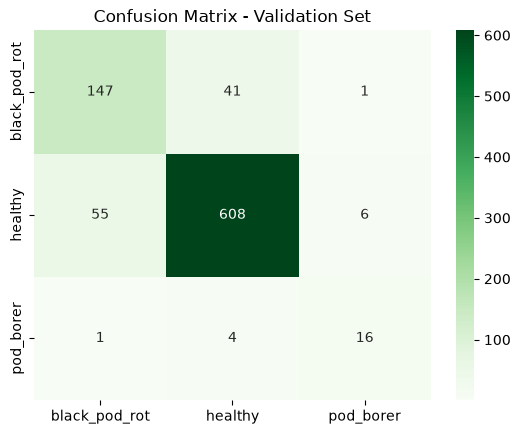

               precision    recall  f1-score   support

black_pod_rot       0.72      0.78      0.75       189
      healthy       0.93      0.91      0.92       669
    pod_borer       0.70      0.76      0.73        21

     accuracy                           0.88       879
    macro avg       0.78      0.82      0.80       879
 weighted avg       0.88      0.88      0.88       879



In [12]:
best_model = tf.keras.models.load_model(checkpoint_path)

val_pred = best_model.predict(val_generator)
val_pred_classes = np.argmax(val_pred, axis=1)
val_true_classes = val_generator.classes

cm_result = confusion_matrix(val_true_classes, val_pred_classes)
sns.heatmap(cm_result, annot=True, fmt="d", cmap="Greens",
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title("Confusion Matrix - Validation Set")
plt.show()

print(classification_report(val_true_classes, val_pred_classes, target_names=CLASSES))


## 13. Precision, Recall, F1-score per Kelas
Grafik batang untuk melihat performa model pada masing-masing kelas secara terpisah.

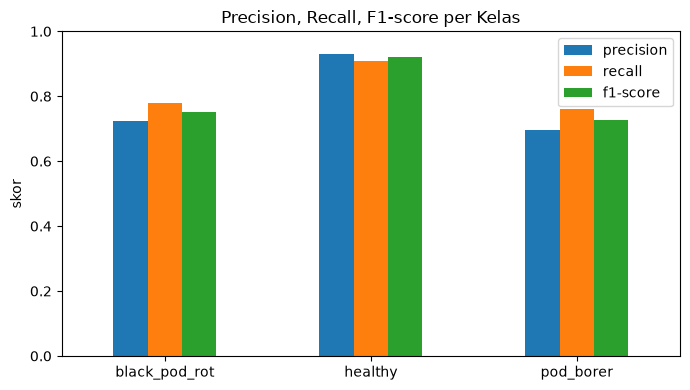

               precision  recall  f1-score
black_pod_rot      0.724   0.778     0.750
healthy            0.931   0.909     0.920
pod_borer          0.696   0.762     0.727


In [13]:
precision, recall, f1, support = precision_recall_fscore_support(
    val_true_classes, val_pred_classes, labels=range(len(CLASSES)))

df_metrik = pd.DataFrame({"precision": precision, "recall": recall, "f1-score": f1}, index=CLASSES)
df_metrik.plot(kind="bar", figsize=(7, 4), ylim=(0, 1))
plt.title("Precision, Recall, F1-score per Kelas")
plt.ylabel("skor")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(df_metrik.round(3))


## 14. Kurva ROC per Kelas
Karena ada 3 kelas, ROC dihitung dengan pendekatan one-vs-rest untuk masing-masing kelas.

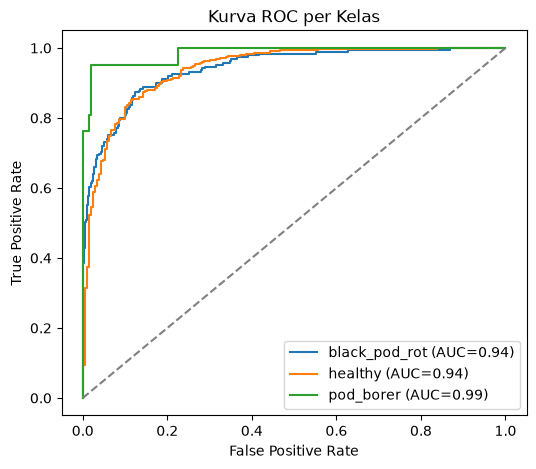

In [14]:
val_true_onehot = label_binarize(val_true_classes, classes=range(len(CLASSES)))

plt.figure(figsize=(6, 5))
for i, kelas in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve(val_true_onehot[:, i], val_pred[:, i])
    skor_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{kelas} (AUC={skor_auc:.2f})")

plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Kurva ROC per Kelas")
plt.legend()
plt.show()


## 15. Kurva Akurasi & Loss

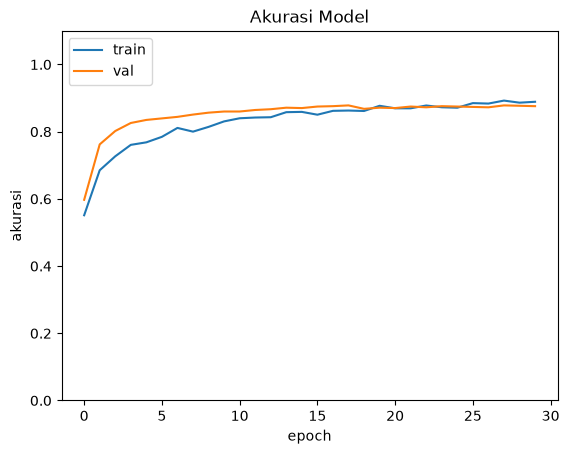

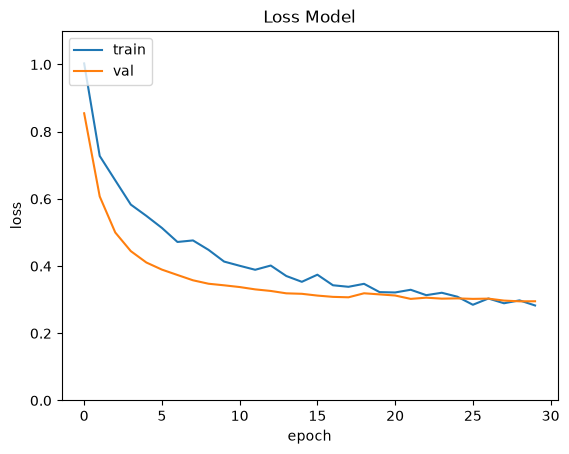

In [16]:
def plot_kurva(kunci_train, kunci_val, judul, ylabel):
    plt.plot(history.history[kunci_train])
    plt.plot(history.history[kunci_val])
    plt.title(judul)
    plt.ylabel(ylabel)
    plt.xlabel("epoch")
    plt.ylim(0, 1.1)
    plt.legend(["train", "val"], loc="upper left")
    plt.show()

# pilih kunci akurasi yang tersedia agar tidak KeyError
if "sparse_categorical_accuracy" in history.history:
    acc_kunci, val_acc_kunci = "sparse_categorical_accuracy", "val_sparse_categorical_accuracy"
elif "accuracy" in history.history:
    acc_kunci, val_acc_kunci = "accuracy", "val_accuracy"
else:
    acc_kunci = val_acc_kunci = None

if acc_kunci:
    plot_kurva(acc_kunci, val_acc_kunci, "Akurasi Model", "akurasi")
else:
    print("Tidak ada metrik akurasi di history. Keys yang tersedia:", list(history.history.keys()))
plot_kurva("loss", "val_loss", "Loss Model", "loss")


## 16. Ringkasan Hyperparameter & Waktu Training
Tabel ringkas untuk dicantumkan di laporan/slide presentasi.

In [18]:
import pandas as pd

# Mengambil nilai pada epoch terakhir
# ambil training accuracy dari history dengan fallback ke nama metrik yang tersedia
if "sparse_categorical_accuracy" in history.history:
    train_acc = history.history["sparse_categorical_accuracy"][-1]
elif "accuracy" in history.history:
    train_acc = history.history["accuracy"][-1]
elif "acc" in history.history:
    train_acc = history.history["acc"][-1]
else:
    train_acc = None

# pastikan key val_sparse_categorical_accuracy ada agar baris berikutnya tidak melempar KeyError
if "val_sparse_categorical_accuracy" not in history.history:
    if "val_accuracy" in history.history:
        history.history["val_sparse_categorical_accuracy"] = history.history["val_accuracy"]
    elif "val_acc" in history.history:
        history.history["val_sparse_categorical_accuracy"] = history.history["val_acc"]
    else:
        # buat fallback list berukuran sama dengan salah satu history key agar indexing [-1] tidak error
        any_key = next(iter(history.history))
        history.history["val_sparse_categorical_accuracy"] = [None] * len(history.history[any_key])
val_acc = history.history['val_sparse_categorical_accuracy'][-1]

train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]

ringkasan = pd.DataFrame({
    "Parameter": [
        "Ukuran Gambar",
        "Batch Size",
        "Learning Rate",
        "Optimizer",
        "Epoch",
        "Jumlah Data Training",
        "Jumlah Data Validasi",
        "Training Accuracy",
        "Validation Accuracy",
        "Training Loss",
        "Validation Loss",
        "Total Waktu Training",
        "Rata-rata Waktu / Epoch"
    ],
    "Nilai": [
        f"{IMG_HEIGHT} x {IMG_WIDTH}",
        BATCH_SIZE,
        LEARNING_RATE,
        "Adam",
        f"{epoch_jalan}/{EPOCHS}",
        train_generator.samples,
        val_generator.samples,
        f"{train_acc*100:.2f} %",
        f"{val_acc*100:.2f} %",
        f"{train_loss:.4f}",
        f"{val_loss:.4f}",
        f"{durasi_detik/60:.2f} menit",
        f"{durasi_detik/epoch_jalan:.2f} detik"
    ]
})

display(ringkasan)

,Parameter,Nilai
0,Ukuran Gambar,224 x 224
1,Batch Size,16
2,Learning Rate,0.0001
3,Optimizer,Adam
4,Epoch,30/30
5,Jumlah Data Training,2262
6,Jumlah Data Validasi,879
7,Training Accuracy,88.90 %
8,Validation Accuracy,87.60 %
9,Training Loss,0.2828


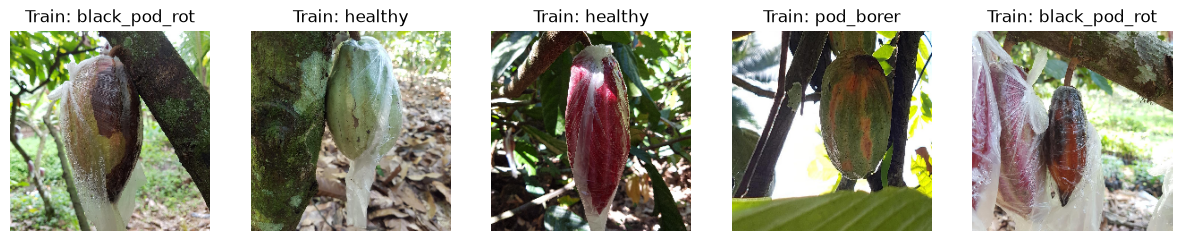

In [19]:
import matplotlib.pyplot as plt

# ==========================================
# 1. TAMPILKAN 5 DATA TRAIN (Hasil Augmentasi)
# ==========================================
# Mengambil satu batch data dari train_generator
train_images, train_labels = next(train_generator) 

plt.figure(figsize=(15, 6)) 

for i in range(5): 
    ax = plt.subplot(2, 5, i + 1) 
    # .astype('uint8') diperlukan karena data gambar bertipe float (0-255)
    # (Rescaling / pembagian 255 dilakukan di dalam layer model EfficientNet)
    plt.imshow(train_images[i].astype('uint8')) 
    # Karena class_mode="sparse", label berupa indeks integer langsung (tidak perlu .argmax())
    plt.title(f"Train: {CLASSES[int(train_labels[i])]}") 
    plt.axis("off") 



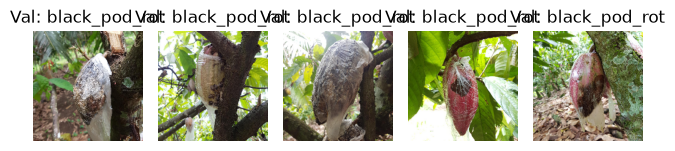

In [20]:
# ==========================================
# 2. TAMPILKAN 5 DATA VALIDATION (TEST)
# ==========================================
# Mengambil satu batch data dari val_generator (karena di proyek Anda menggunakan val_generator)
val_images, val_labels = next(val_generator) 

for i in range(5): 
    ax = plt.subplot(2, 5, i + 6) 
    plt.imshow(val_images[i].astype('uint8')) 
    plt.title(f"Val: {CLASSES[int(val_labels[i])]}") 
    plt.axis("off") 

plt.tight_layout() 
plt.show()